In [8]:
import os
import glob
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

In [9]:

DATA_DIR = 'parsed_graphs'                  
TARGET_GRAPH_FILE = 'SO_36S16O_graph.pt'      
INFERENCE_TARGET = 'CO2_728_graph.pt'       
CORRUPTION_RATE = 0.08                      
ERROR_WEIGHTS = {                           
    'qn_shift': 0.40,                       
    'qn_swap': 0.30,                        
    'random_relink': 0.30                   
}
TRAIN_SPLIT_RATIO = 0.80                        
NUM_LAYERS = 3                              
HIDDEN_DIM = 64                             
LEARNING_RATE = 0.001                       
WEIGHT_DECAY = 1e-4                        
EPOCHS = 300                               
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42


torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Using compute device: {DEVICE}")


Using compute device: cuda


In [10]:
def build_qn_neighbor_map(state_qns, num_nodes):

    if not state_qns or len(state_qns) == 0:
        return {}

    numeric_qns = []
    for qn in state_qns:
        num_vec = []
        for val in qn:
            try:
                num_vec.append(float(val))
            except ValueError:
                num_vec.append(hash(str(val)) % 1000)
        numeric_qns.append(np.array(num_vec))
    numeric_qns = np.array(numeric_qns)

    neighbor_map = {}
    for i in range(num_nodes):
        start = max(0, i - 100)
        end = min(num_nodes, i + 100)
        window = numeric_qns[start:end]
        diffs = np.sum(np.abs(window - numeric_qns[i]), axis=1)
        valid_local = np.where((diffs > 0) & (diffs <= 2.0))[0]
        
        if len(valid_local) > 0:
            neighbor_map[i] = (start + valid_local).tolist()
        else:
            neighbor_map[i] = [max(0, i - 1), min(num_nodes - 1, i + 1)]

    return neighbor_map


def perturb_transitions(raw_data, corruption_rate=CORRUPTION_RATE, error_weights=ERROR_WEIGHTS, neighbor_map=None):
    num_nodes = raw_data.num_nodes if hasattr(raw_data, 'num_nodes') and raw_data.num_nodes is not None else raw_data.x.shape[0]
    total_directed_edges = raw_data.edge_index.shape[1]
    num_transitions = total_directed_edges // 2


    src_nodes = raw_data.edge_index[0, :num_transitions].clone().cpu().numpy()
    dst_nodes = raw_data.edge_index[1, :num_transitions].clone().cpu().numpy()
    fwd_attr = raw_data.edge_attr[:num_transitions].clone().cpu().numpy()

    num_corrupt = max(1, int(num_transitions * corruption_rate))
    corrupt_indices = np.random.choice(num_transitions, size=num_corrupt, replace=False)
    corrupt_mask = np.zeros(num_transitions, dtype=bool)
    corrupt_mask[corrupt_indices] = True

    types = list(error_weights.keys())
    probs = np.array([error_weights[t] for t in types])
    probs = probs / probs.sum()

    for idx in corrupt_indices:
        err_type = np.random.choice(types, p=probs)
        u, v = src_nodes[idx], dst_nodes[idx]

        if err_type == 'qn_shift':
            target_node = v if np.random.rand() > 0.5 else u
            if neighbor_map and target_node in neighbor_map and len(neighbor_map[target_node]) > 0:
                new_node = np.random.choice(neighbor_map[target_node])
            else:
                offset = np.random.choice([-2, -1, 1, 2])
                new_node = int(np.clip(target_node + offset, 0, num_nodes - 1))
            
            if target_node == v:
                dst_nodes[idx] = new_node
            else:
                src_nodes[idx] = new_node

        elif err_type == 'qn_swap':
            src_nodes[idx] = v
            dst_nodes[idx] = u

        elif err_type == 'random_relink':
            rand_node = np.random.randint(0, num_nodes)
            while rand_node == u:
                rand_node = np.random.randint(0, num_nodes)
            dst_nodes[idx] = rand_node


    new_src = np.concatenate([src_nodes, dst_nodes])
    new_dst = np.concatenate([dst_nodes, src_nodes])
    edge_index = torch.tensor(np.stack([new_src, new_dst]), dtype=torch.long)


    rev_attr = fwd_attr.copy()
    rev_attr[:, 0] = -rev_attr[:, 0]
    edge_attr = torch.tensor(np.concatenate([fwd_attr, rev_attr], axis=0), dtype=torch.float)

    fwd_labels = corrupt_mask.astype(np.float32)
    edge_labels = torch.tensor(np.concatenate([fwd_labels, fwd_labels]), dtype=torch.float)

    corrupted_data = Data(
        edge_index=edge_index,
        edge_attr=edge_attr,
        edge_label=edge_labels,
        num_nodes=num_nodes,
        num_transitions=num_transitions,
        num_corrupt=num_corrupt,
        molecule_name=getattr(raw_data, 'molecule_name', 'Unknown')
    )

    return corrupted_data

In [11]:
class SpectroConv(MessagePassing):
    def __init__(self, hidden_dim):
        super(SpectroConv, self).__init__(aggr='mean')

        self.msg_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.energy_proj = nn.Linear(1, hidden_dim)

        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        trans_E = edge_attr[:, 0:1]
        state_interaction = self.msg_mlp(torch.cat([x_i, x_j], dim=-1))
        energy_shift = self.energy_proj(trans_E)
        return state_interaction + energy_shift

    def update(self, aggr_out, x):
        new_state = torch.cat([x, aggr_out], dim=-1)
        return self.update_mlp(new_state) + x


class TransitionAnomalyGNN(nn.Module):
    def __init__(self, num_layers=NUM_LAYERS, hidden_dim=HIDDEN_DIM):
        super().__init__()


        self.init_node_feature = nn.Parameter(torch.zeros(1, hidden_dim))

        self.convs = nn.ModuleList([
            SpectroConv(hidden_dim) for _ in range(num_layers)
        ])


        in_dim = (2 * hidden_dim) + 2
        self.edge_classifier = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, edge_index, edge_attr, num_nodes=None):
        if num_nodes is None:
            num_nodes = int(edge_index.max().item()) + 1


        h = self.init_node_feature.expand(num_nodes, -1)

        for conv in self.convs:
            h = conv(h, edge_index, edge_attr)


        u_nodes = edge_index[0]
        v_nodes = edge_index[1]

        h_u = h[u_nodes]
        h_v = h[v_nodes]
        h_diff = h_v - h_u
        h_diff_abs = torch.abs(h_diff)

        edge_features = torch.cat([h_diff, h_diff_abs, edge_attr], dim=-1)
        edge_logits = self.edge_classifier(edge_features).squeeze(-1)

        return edge_logits


In [12]:
def train_and_evaluate(raw_data, epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE):
    print(f"Training on {getattr(raw_data, 'molecule_name', 'Graph')}")

    num_nodes = raw_data.num_nodes if hasattr(raw_data, 'num_nodes') and raw_data.num_nodes is not None else raw_data.x.shape[0]
    total_directed_edges = raw_data.edge_index.shape[1]
    num_transitions = total_directed_edges // 2

  
    neighbor_map = build_qn_neighbor_map(getattr(raw_data, 'state_qns', None), num_nodes)


    indices = np.random.permutation(num_transitions)
    split_idx = int(num_transitions * TRAIN_SPLIT_RATIO)
    train_trans_idx = indices[:split_idx]
    val_trans_idx = indices[split_idx:]

    model = TransitionAnomalyGNN(num_layers=NUM_LAYERS, hidden_dim=HIDDEN_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    pos_weight_val = (1.0 - CORRUPTION_RATE) / CORRUPTION_RATE
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val], device=device))

    print(f"Nodes: {num_nodes:,} | Total Transitions: {num_transitions:,} | Corruption Rate: {CORRUPTION_RATE*100:.1f}%")
    print(f"Train Transitions: {len(train_trans_idx):,} | Val Transitions: {len(val_trans_idx):,}")
    print(f"Class Imbalance Pos Weight: {pos_weight_val:.2f} | Device: {device}\n")

    train_loss_history = []
    val_loss_history = []
    val_roc_history = []
    val_pr_history = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        graph_data = perturb_transitions(raw_data, corruption_rate=CORRUPTION_RATE, neighbor_map=neighbor_map).to(device)

        train_mask = torch.tensor(train_trans_idx, dtype=torch.long, device=device)
        val_mask = torch.tensor(val_trans_idx, dtype=torch.long, device=device)


        model.train()
        optimizer.zero_grad()

        edge_logits = model(graph_data.edge_index, graph_data.edge_attr, num_nodes=num_nodes)
        train_logits = edge_logits[train_mask]
        train_targets = graph_data.edge_label[train_mask]
        train_loss = loss_fn(train_logits, train_targets)

        train_loss.backward()
        optimizer.step()

   
        model.eval()
        with torch.no_grad():
            val_logits = edge_logits[val_mask]
            val_targets = graph_data.edge_label[val_mask]
            val_loss = loss_fn(val_logits, val_targets)

            val_probs = torch.sigmoid(val_logits).cpu().numpy()
            val_true = val_targets.cpu().numpy()

            val_roc = roc_auc_score(val_true, val_probs) if len(np.unique(val_true)) > 1 else 0.5
            val_pr = average_precision_score(val_true, val_probs) if len(np.unique(val_true)) > 1 else 0.0

        train_loss_history.append(train_loss.item())
        val_loss_history.append(val_loss.item())
        val_roc_history.append(val_roc)
        val_pr_history.append(val_pr)

        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}/{epochs:03d} | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val ROC-AUC: {val_roc:.4f} | Val PR-AUC: {val_pr:.4f}", flush=True)

    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed:.2f}s.")


    model.eval()
    with torch.no_grad():
        final_data = perturb_transitions(raw_data, corruption_rate=CORRUPTION_RATE, neighbor_map=neighbor_map).to(device)
        val_mask = torch.tensor(val_trans_idx, dtype=torch.long, device=device)
        logits = model(final_data.edge_index, final_data.edge_attr, num_nodes=num_nodes)[val_mask]
        probs = torch.sigmoid(logits).cpu().numpy()
        targets = final_data.edge_label[val_mask].cpu().numpy()

    final_roc = roc_auc_score(targets, probs)
    final_pr_auc = average_precision_score(targets, probs)

    precision_curve, recall_curve, thresholds = precision_recall_curve(targets, probs)
    f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
    best_thresh_idx = np.argmax(f1_scores)
    best_threshold = float(thresholds[best_thresh_idx]) if best_thresh_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_thresh_idx]

    preds_binary = (probs >= best_threshold).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(targets, preds_binary, average='binary', zero_division=0)
    cm = confusion_matrix(targets, preds_binary)
    print(f" ROC-AUC Score:             {final_roc:.4f}")



    fig, axs = plt.subplots(1, 3, figsize=(18, 5))


    axs[0].plot(train_loss_history, label='Train Loss', color='royalblue')
    axs[0].plot(val_loss_history, label='Val Loss', color='crimson')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Weighted BCE Loss')
    axs[0].set_title('Training & Validation Loss')
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.6)

    fpr, tpr, _ = roc_curve(targets, probs)
    axs[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {final_roc:.3f})')
    axs[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive Rate')
    axs[1].set_title('Receiver Operating Characteristic')
    axs[1].legend(loc='lower right')
    axs[1].grid(True, linestyle='--', alpha=0.6)


    clean_scores = probs[targets == 0]
    bad_scores = probs[targets == 1]
    axs[2].hist(clean_scores, bins=30, alpha=0.6, color='seagreen', label=f'Clean (N={len(clean_scores)})')
    axs[2].hist(bad_scores, bins=30, alpha=0.6, color='firebrick', label=f'Corrupted (N={len(bad_scores)})')
    axs[2].axvline(best_threshold, color='black', linestyle=':', lw=2, label=f'Thresh ({best_threshold:.2f})')
    axs[2].set_xlabel('Predicted Corruption Probability')
    axs[2].set_ylabel('Count')
    axs[2].set_title('Anomaly Score Separation')
    axs[2].legend()
    axs[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    return model, best_threshold


Loading training graph from: parsed_graphs\SO_36S16O_graph.pt
Loaded SO_36S16O: 5,366 nodes, 35,668 transitions
Training on SO_36S16O
Nodes: 5,366 | Total Transitions: 35,668 | Corruption Rate: 8.0%
Train Transitions: 28,534 | Val Transitions: 7,134
Class Imbalance Pos Weight: 11.50 | Device: cuda

Epoch 001/300 | Train Loss: 1.2734 | Val Loss: 1.2570 | Val ROC-AUC: 0.5621 | Val PR-AUC: 0.0976
Epoch 050/300 | Train Loss: 1.0631 | Val Loss: 1.0494 | Val ROC-AUC: 0.6744 | Val PR-AUC: 0.4393
Epoch 100/300 | Train Loss: 1.0592 | Val Loss: 1.0679 | Val ROC-AUC: 0.6588 | Val PR-AUC: 0.4085
Epoch 150/300 | Train Loss: 1.0482 | Val Loss: 1.0423 | Val ROC-AUC: 0.6605 | Val PR-AUC: 0.4144
Epoch 200/300 | Train Loss: 1.0296 | Val Loss: 1.0594 | Val ROC-AUC: 0.6452 | Val PR-AUC: 0.3968
Epoch 250/300 | Train Loss: 1.0211 | Val Loss: 1.0610 | Val ROC-AUC: 0.6761 | Val PR-AUC: 0.4407
Epoch 300/300 | Train Loss: 1.0483 | Val Loss: 1.0419 | Val ROC-AUC: 0.6856 | Val PR-AUC: 0.4276

Training completed i

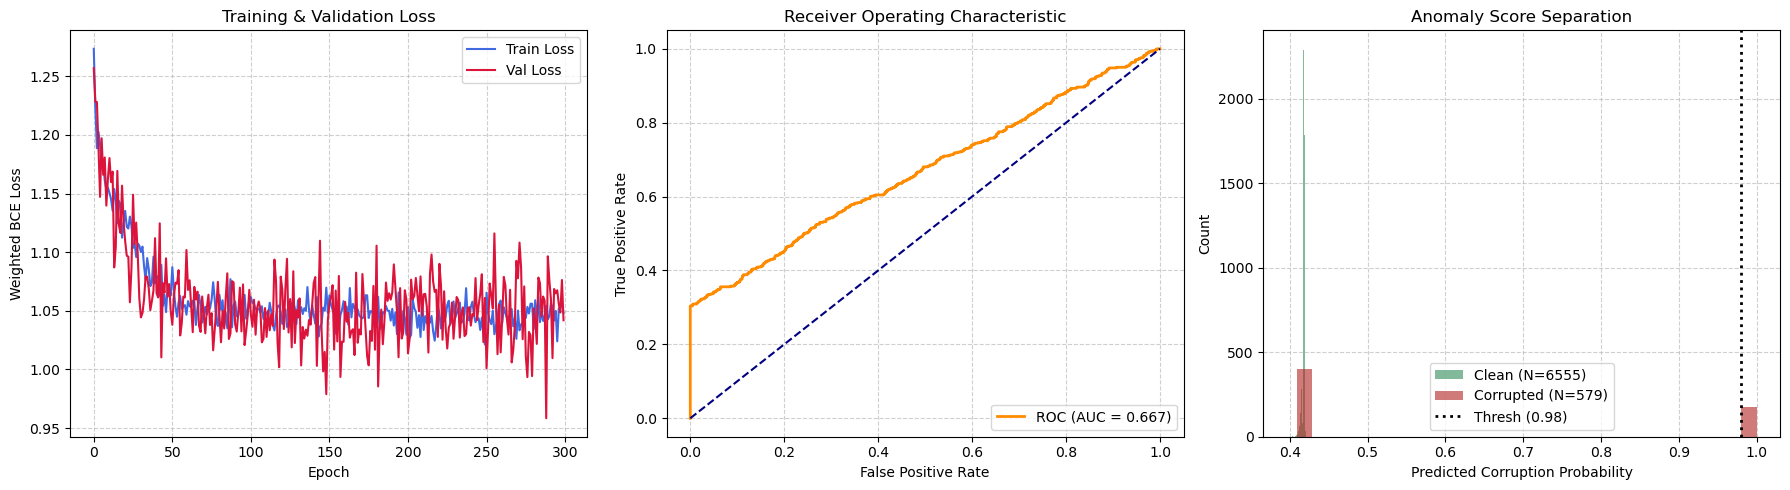

In [13]:

target_file = os.path.join(DATA_DIR, TARGET_GRAPH_FILE)
print(f"Loading training graph from: {target_file}")
raw_data = torch.load(target_file, weights_only=False)
print(f"Loaded {getattr(raw_data, 'molecule_name', 'Graph')}: {raw_data.num_nodes:,} nodes, {raw_data.edge_index.shape[1]//2:,} transitions")

model, best_threshold = train_and_evaluate(raw_data, epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE)


In [14]:

if INFERENCE_TARGET:
    infer_file = os.path.join(DATA_DIR, INFERENCE_TARGET)

    print(f"INFERENCE: {INFERENCE_TARGET}")
    
    infer_data = torch.load(infer_file, weights_only=False)
    infer_nodes = infer_data.num_nodes if hasattr(infer_data, 'num_nodes') and infer_data.num_nodes is not None else infer_data.x.shape[0]
    infer_transitions = infer_data.edge_index.shape[1] // 2
    
    print(f"Loaded {getattr(infer_data, 'molecule_name', 'Graph')}: {infer_nodes:,} nodes, {infer_transitions:,} transitions")
    
    model.eval()
    with torch.no_grad():

        infer_logits = model(infer_data.edge_index.to(DEVICE), infer_data.edge_attr.to(DEVICE), num_nodes=infer_nodes)
        fwd_logits = infer_logits[:infer_transitions]
        fwd_probs = torch.sigmoid(fwd_logits).cpu().numpy()
        
    print(f" - Mean Anomaly Probability:   {fwd_probs.mean():.4f}")
    print(f" - Median Anomaly Probability: {np.median(fwd_probs):.4f}")
    print(f" - Std Deviation:              {fwd_probs.std():.4f}")
    print(f" - Min / Max Probability:      {fwd_probs.min():.4f} / {fwd_probs.max():.4f}")
    

    threshold = best_threshold if 'best_threshold' in locals() else 0.5
    flagged_indices = np.where(fwd_probs >= threshold)[0]
    flagged_count = len(flagged_indices)
    flagged_pct = (flagged_count / infer_transitions) * 100
    
    print(f"\nThreshold = {threshold:.4f}")
    print(f" - Flagged: {flagged_count:,} / {infer_transitions:,} ({flagged_pct:.2f}%)")
    print(f" - Clean:   {infer_transitions - flagged_count:,} / {infer_transitions:,} ({100 - flagged_pct:.2f}%)")
    

    top_k = min(15, infer_transitions)
    top_indices = np.argsort(-fwd_probs)[:top_k]
    
    src = infer_data.edge_index[0, :infer_transitions].cpu().numpy()
    dst = infer_data.edge_index[1, :infer_transitions].cpu().numpy()
    wavenumbers = infer_data.edge_attr[:infer_transitions, 0].cpu().numpy()
    uncertainties = infer_data.edge_attr[:infer_transitions, 1].cpu().numpy()
    
    print(f"\nTop {top_k} Highest anomaly scores in {INFERENCE_TARGET}:")
    print(f"{'Rank':<5} {'Trans Idx':<10} {'From ID':<9} {'To ID':<9} {'Wavenumber (cm^-1)':<20} {'Uncertainty':<14} {'Anomaly Prob':<12}")
    for rank, idx in enumerate(top_indices, 1):
        u_idx, v_idx = src[idx], dst[idx]
        wn = wavenumbers[idx]
        unc = uncertainties[idx]
        prob = fwd_probs[idx]
        print(f"{rank:<5} {idx:<10} {u_idx:<9} {v_idx:<9} {wn:<20.6f} {unc:<14.2e} {prob:<12.4f}")


INFERENCE: CO2_728_graph.pt
Loaded CO2_728: 4,546 nodes, 11,338 transitions
 - Mean Anomaly Probability:   0.4182
 - Median Anomaly Probability: 0.4173
 - Std Deviation:              0.0251
 - Min / Max Probability:      0.3940 / 0.9979

Threshold = 0.9798
 - Flagged: 10 / 11,338 (0.09%)
 - Clean:   11,328 / 11,338 (99.91%)

Top 15 Highest anomaly scores in CO2_728_graph.pt:
Rank  Trans Idx  From ID   To ID     Wavenumber (cm^-1)   Uncertainty    Anomaly Prob
1     36         4141      36        653.310974           3.00e-03       0.9979      
2     52         4135      28        671.236023           3.00e-03       0.9979      
3     19         4124      19        641.419006           3.00e-03       0.9970      
4     63         4124      17        679.283020           3.00e-03       0.9965      
5     44         4144      43        664.002014           3.00e-03       0.9935      
6     40         4145      40        656.861023           3.00e-03       0.9934      
7     28         413